### Блок 2. Распределение value и статистические свойства

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory


#### Подготовка и вспомогательный функции 

In [2]:
dist_data = pd.read_excel('data/final_data.xlsx')
dist_data["rep_date"] = pd.to_datetime(dist_data["rep_date"])
dist_data = dist_data.sort_values(["rep_date", "country", "hs"]).reset_index(drop=True)

# Добавляем год
dist_data["year"] = dist_data["rep_date"].dt.year
# Бинарный индикатор положительного импорта
dist_data["is_positive"] = (dist_data["value"] > 0).astype(int)
# Положительные наблюдения отдельно
positive_data = dist_data[dist_data["value"] > 0].copy()

In [3]:
shock_date = pd.Timestamp("2022-02-01")

# Создаем папку для сохранения рисунков
save_dir = "figures/eda_block_2"
os.makedirs(save_dir, exist_ok=True)

In [4]:
def human_format(x, pos):
    abs_x = abs(x)
    if abs_x >= 1e9:
        return f"{x/1e9:.1f}B"
    elif abs_x >= 1e6:
        return f"{x/1e6:.1f}M"
    elif abs_x >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"

def apply_style(ax, title, ylabel=None, xlabel=None, shade_post=False):
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12, labelpad=15)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12, labelpad=15)

    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.5)
    ax.spines["bottom"].set_alpha(0.5)
    ax.tick_params(axis="both", labelsize=11)

    if shade_post:
        # правая граница именно текущей оси
        x_left = mdates.date2num(shock_date)
        x_right = ax.get_xlim()[1]

        # красим до конца графика
        ax.axvspan(x_left, x_right, alpha=0.08, color="#B22222")
        ax.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

        # X в координатах данных, Y в долях оси
        trans = blended_transform_factory(ax.transData, ax.transAxes)

        # подпись чуть левее правого края красной зоны
        x_text = x_right - 0.02 * (x_right - x_left)

        ax.text(
            x_text, 0.04,
            "Постсанкционный период",
            transform=trans,
            color="#8B0000",
            fontsize=10,
            ha="right",
            va="bottom",
            linespacing=1.0
        )

def save_figure(fig, filename):
    fig.savefig(os.path.join(save_dir, f"{filename}.png"), dpi=400, bbox_inches="tight")
    plt.show()
    plt.close(fig)

#### Описательная статистика

In [5]:
summary_stats = pd.DataFrame({
    "metric": [
        "Количество наблюдений",
        "Количество нулевых наблюдений",
        "Доля нулевых наблюдений, %",
        "Среднее",
        "Медиана",
        "Стандартное отклонение",
        "Минимум",
        "25-й перцентиль",
        "75-й перцентиль",
        "90-й перцентиль",
        "95-й перцентиль",
        "99-й перцентиль",
        "Максимум"
    ],
    "value": [
        len(dist_data),
        (dist_data["value"] == 0).sum(),
        round((dist_data["value"] == 0).mean() * 100, 2),
        dist_data["value"].mean(),
        dist_data["value"].median(),
        dist_data["value"].std(),
        dist_data["value"].min(),
        dist_data["value"].quantile(0.25),
        dist_data["value"].quantile(0.75),
        dist_data["value"].quantile(0.90),
        dist_data["value"].quantile(0.95),
        dist_data["value"].quantile(0.99),
        dist_data["value"].max()
    ]
})

summary_stats

,metric,value
0,Количество наблюдений,4.843800e+04
1,Количество нулевых наблюдений,2.678400e+04
2,"Доля нулевых наблюдений, %",5.530000e+01
3,Среднее,6.937184e+05
4,Медиана,0.000000e+00
5,Стандартное отклонение,3.427838e+06
6,Минимум,0.000000e+00
7,25-й перцентиль,0.000000e+00
8,75-й перцентиль,1.117893e+05
9,90-й перцентиль,1.012302e+06


Описательная статистика подтверждает, что распределение стоимостного импорта обладает всеми признаками сильно несбалансированной и асимметричной переменной. При общем числе наблюдений 48 438 более половины значений равны нулю, поэтому медиана по всей выборке также равна нулю. Среднее значение составляет около 694 тыс. долл. США, однако оно существенно завышается за счет крупных поставок, о чем свидетельствует очень высокий разрыв между средним и квартилями: уже 75-й перцентиль составляет лишь около 112 тыс. долл., тогда как 95-й — более 3,0 млн долл., 99-й — 14,1 млн долл., а максимум превышает 108,7 млн долл. США. Стандартное отклонение, многократно превосходящее среднее, также указывает на чрезвычайно высокую вариативность данных. В совокупности эти результаты показывают, что импорт медицинского оборудования в стоимостном выражении распределен крайне неравномерно: основная масса наблюдений приходится на нулевые или небольшие значения, тогда как общий объем формируется сравнительно небольшим числом крупных поставок.

#### ГРАФИК 1. ДОЛЯ НУЛЕВЫХ И ПОЛОЖИТЕЛЬНЫХ НАБЛЮДЕНИЙ

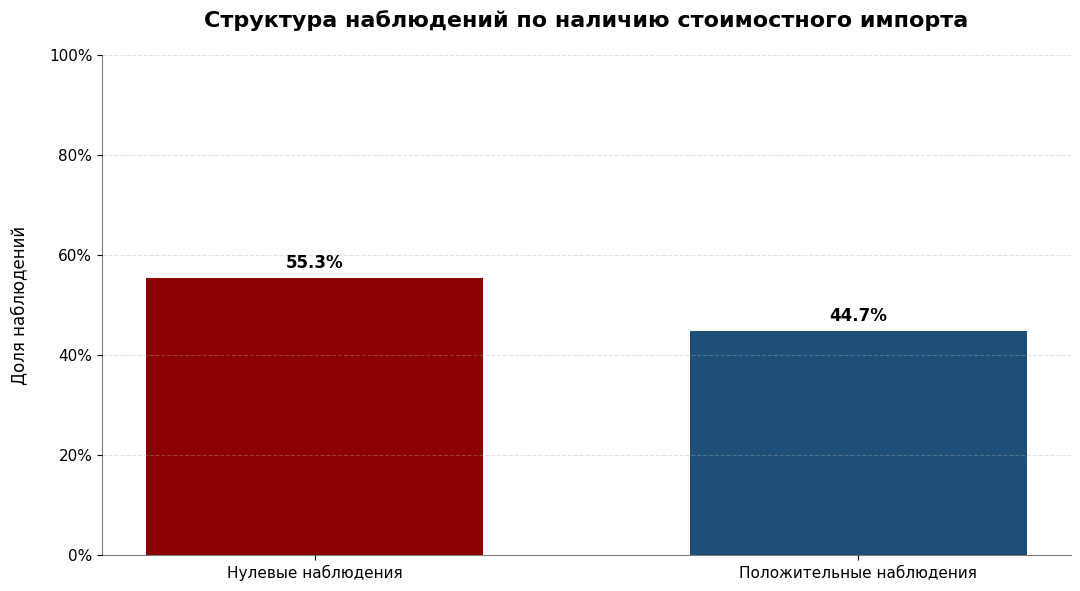

In [37]:
zero_share = (dist_data["value"] == 0).mean() * 100
positive_share = 100 - zero_share

fig, ax = plt.subplots(figsize=(12.5, 6.5))

categories = ["Нулевые наблюдения", "Положительные наблюдения"]
shares = [zero_share, positive_share]
colors = ["#8B0000", "#1F4E79"]

bars = ax.bar(categories, shares, color=colors, width=0.62)

for bar, val in zip(bars, shares):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.2,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())
apply_style(
    ax,
    title="Структура наблюдений по наличию стоимостного импорта",
    ylabel="Доля наблюдений"
)

save_figure(fig, "01_zero_vs_positive_share")

График показывает, что в выборке преобладают нулевые наблюдения: их доля составляет 55,3%, тогда как положительные значения фиксируются лишь в 44,7% случаев. Это означает, что панель импорта медицинского оборудования имеет выраженно разреженный характер: более чем в половине комбинаций страна–HS–месяц поставки в стоимостном выражении отсутствуют. Такая структура данных типична для внешнеторговых панелей на дезагрегированном уровне и подтверждает, что использование методов, корректно работающих с большим числом нулей, является принципиально важным. Одновременно этот результат указывает на высокую неоднородность торговых потоков: импорт по многим направлениям носит эпизодический, а не устойчивый характер.

#### ГРАФИК 2. ДОЛЯ НУЛЕВЫХ НАБЛЮДЕНИЙ ПО МЕСЯЦАМ

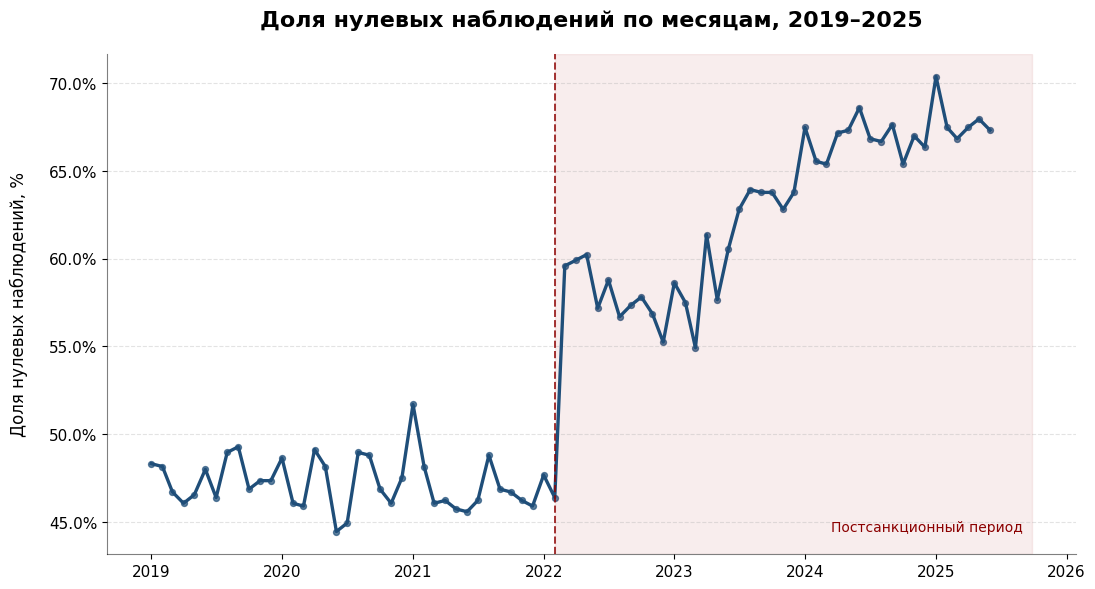

In [36]:
zero_share_monthly = (
    dist_data.groupby("rep_date", as_index=False)["value"]
    .apply(lambda x: (x == 0).mean() * 100)
    .rename(columns={"value": "zero_share_pct"})
)

fig, ax = plt.subplots(figsize=(12.5, 6.5))

ax.plot(
    zero_share_monthly["rep_date"],
    zero_share_monthly["zero_share_pct"],
    color="#1F4E79",
    linewidth=2.4
)

ax.scatter(
    zero_share_monthly["rep_date"],
    zero_share_monthly["zero_share_pct"],
    color="#1F4E79",
    s=18,
    alpha=0.7
)

apply_style(
    ax,
    title="Доля нулевых наблюдений по месяцам, 2019–2025",
    ylabel="Доля нулевых наблюдений, %",
    shade_post=True
)

ax.yaxis.set_major_formatter(PercentFormatter())

save_figure(fig, "02_zero_share_monthly")

Динамика доли нулевых наблюдений во времени свидетельствует о явственном структурном сдвиге после начала 2022 года. В 2019–2021 гг. доля нулей была относительно стабильной и колебалась в диапазоне примерно 45–49%, что соответствует более равномерному распределению поставок по странам и товарным категориям. Начиная с 2022 года этот показатель резко возрастает, а в последующие годы закрепляется на существенно более высоком уровне, достигая 65–70% к 2024–2025 гг. Это означает, что после санкционного шока импорт стал наблюдаться в меньшем числе пар страна–HS–месяц, то есть торговые потоки стали более выборочными и менее равномерно распределенными по панели. Иначе говоря, даже при сохранении общего стоимостного импорта его внутренняя структура стала более “пустой”, что указывает на усиление фрагментации и возможное сужение числа реально активных каналов поставок.

#### ГРАФИК 3. РАСПРЕДЕЛЕНИЕ ПОЛОЖИТЕЛЬНЫХ ЗНАЧЕНИЙ VALUE

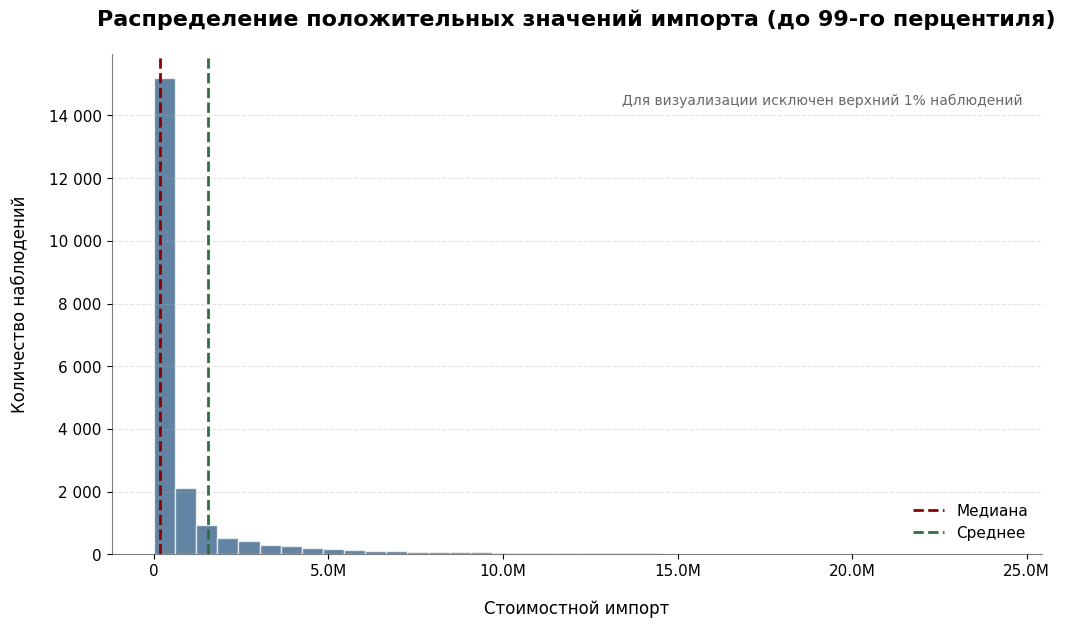

In [39]:
p99 = positive_data["value"].quantile(0.99)
plot_data = positive_data[positive_data["value"] <= p99]["value"]

mean_val = positive_data["value"].mean()
median_val = positive_data["value"].median()

fig, ax = plt.subplots(figsize=(12, 6.5))

ax.hist(
    plot_data,
    bins=40,
    color="#1F4E79",
    edgecolor="white",
    alpha=0.7
)

# Медиана
ax.axvline(
    median_val if median_val <= p99 else plot_data.median(),
    color="#8B0000",
    linestyle="--",
    linewidth=2,
    label="Медиана"
)

# Среднее
if mean_val <= p99:
    ax.axvline(
        mean_val,
        color="#2E6F40",
        linestyle="--",
        linewidth=2,
        label="Среднее"
    )

ax.xaxis.set_major_formatter(FuncFormatter(human_format))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", " ")))

apply_style(
    ax,
    title="Распределение положительных значений импорта (до 99-го перцентиля)",
    ylabel="Количество наблюдений",
    xlabel="Стоимостной импорт"
)

ax.text(
    0.98, 0.92,
    "Для визуализации исключен верхний 1% наблюдений",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    color="dimgray"
)

ax.legend(frameon=False, fontsize=11)

save_figure(fig, "03_distribution_positive_value_trimmed_p99")

Гистограмма положительных значений импорта показывает резко асимметричное распределение с длинным правым хвостом. Основная масса положительных наблюдений сосредоточена вблизи низких значений, тогда как крупные поставки встречаются значительно реже, но формируют очень широкий хвост распределения. Это подтверждается и положением медианы и среднего: среднее заметно выше медианы, что указывает на сильное влияние сравнительно небольшого числа крупных поставок на общий уровень стоимостного импорта. Таким образом, положительные значения импорта не распределены равномерно: большинство поставок имеют небольшой объем, а общая стоимостная динамика в значительной степени определяется отдельными крупными транзакциями. Для дальнейшего анализа это важно, поскольку подобная форма распределения свидетельствует о высокой гетерогенности наблюдений и наличии выраженных выбросов в верхней части распределения.

#### ГРАФИК 4. РАСПРЕДЕЛЕНИЕ ПОЛОЖИТЕЛЬНЫХ ЗНАЧЕНИЙ ПО ГОДАМ

C:\Users\Admin\AppData\Local\Temp\ipykernel_49760\3336949366.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


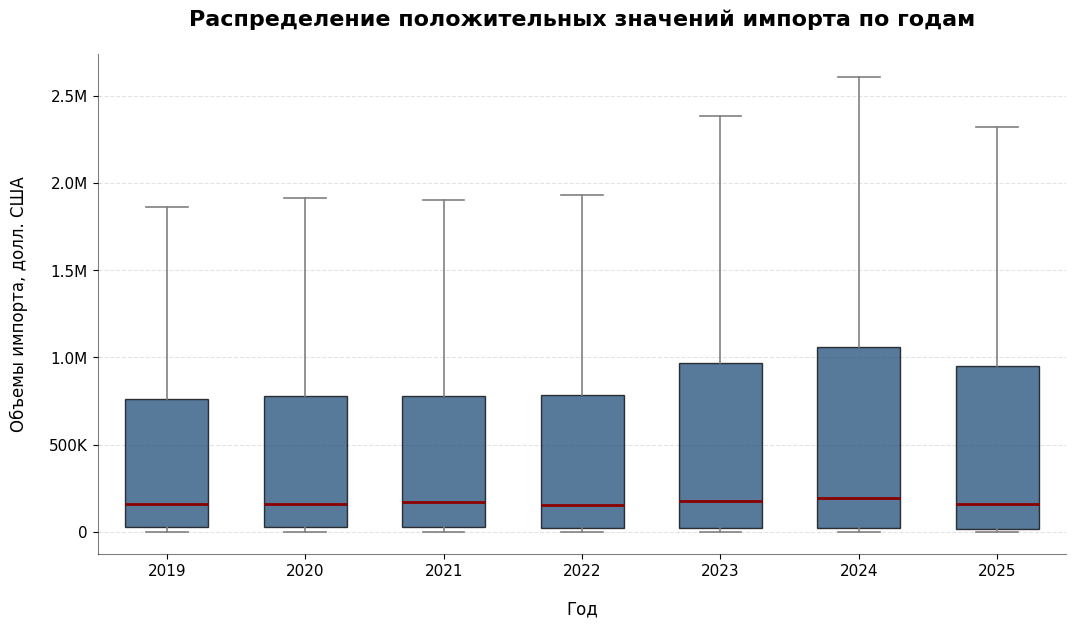

In [ ]:
year_plot_data = positive_data.copy()

years_sorted = sorted(year_plot_data["year"].unique())
box_data = [year_plot_data.loc[year_plot_data["year"] == y, "value"] for y in years_sorted]

fig, ax = plt.subplots(figsize=(12.5, 6.5))

bp = ax.boxplot(
    box_data,
    patch_artist=True,
    labels=years_sorted,
    showfliers=False,
    widths=0.6
)

for box in bp["boxes"]:
    box.set(facecolor="#1F4E79", alpha=0.75)

for median in bp["medians"]:
    median.set(color="#8B0000", linewidth=2)

for whisker in bp["whiskers"]:
    whisker.set(color="gray", linewidth=1.2)

for cap in bp["caps"]:
    cap.set(color="gray", linewidth=1.2)

ax.yaxis.set_major_formatter(FuncFormatter(human_format))

apply_style(
    ax,
    title="Распределение положительных значений импорта по годам",
    ylabel="Объемы импорта, долл. США",
    xlabel="Год"
)


save_figure(fig, "04_boxplot_positive_value_by_year")

Boxplot по годам показывает, что распределение положительных значений импорта остается сильно асимметричным на всем протяжении периода, однако после 2022 года его верхняя часть становится более растянутой. В 2019–2022 гг. межквартильный размах и верхние границы распределения были относительно стабильными, тогда как в 2023–2024 гг. верхние квартили и верхние “усы” заметно смещаются вверх. Это говорит о том, что в постсанкционный период сохраняется значительное число небольших поставок, но одновременно усиливается роль крупных стоимостных партий. Иными словами, после 2022 года импорт становится более поляризованным: наряду с множеством малых поставок возрастает значение отдельных крупных операций. В 2025 году наблюдается некоторое снижение верхней части распределения, однако этот результат следует интерпретировать с осторожностью, поскольку данные представлены только за часть года.

#### ТАБЛИЦА 2. СТАТИСТИКА ПО ГОДАМ

In [53]:
yearly_stats = (
    dist_data.groupby("year", as_index=False)
    .agg(
        observations=("value", "size"),
        zero_share_pct=("value", lambda x: (x == 0).mean() * 100),
        mean_value=("value", "mean"),
        median_value=("value", "median"),
        p90=("value", lambda x: x.quantile(0.90)),
        p95=("value", lambda x: x.quantile(0.95)),
        max_value=("value", "max")
    )
)

yearly_stats

,year,observations,zero_share_pct,mean_value,median_value,p90,p95,max_value
0,2019,7452,47.490607,629755.154946,832.509735,1.079661e+06,3.005837e+06,6.706075e+07
1,2020,7452,47.114868,719262.759259,1081.933731,1.200527e+06,3.376840e+06,6.997789e+07
2,2021,7452,47.007515,746037.881680,1397.345000,1.287530e+06,3.406320e+06,7.906687e+07
3,2022,7452,56.132582,685293.123281,0.000000,9.501568e+05,2.932262e+06,7.833889e+07
4,2023,7452,60.950081,709259.424199,0.000000,9.277991e+05,2.900766e+06,6.466312e+07
5,2024,7452,66.774020,697325.882488,0.000000,7.325358e+05,2.673023e+06,1.087525e+08
6,2025,3726,67.901235,644470.499866,0.000000,6.476023e+05,2.310630e+06,6.926288e+07


Годовая статистика показывает, что до 2022 года доля нулевых наблюдений оставалась практически неизменной и находилась немного выше 47%, тогда как в постсанкционный период она начала быстро расти: до 56,1% в 2022 году, 61,0% в 2023 году, 66,8% в 2024 году и 67,9% в 2025 году. При этом среднее значение импорта по году изменялось намного слабее: после роста в 2019–2021 гг. оно снизилось в 2022 году, затем частично восстановилось, но не вернулось к устойчивому росту. Особенно показательно изменение медианы: если в 2019–2021 гг. она оставалась положительной, то начиная с 2022 года становится равной нулю, что означает, что как минимум половина наблюдений в каждом постсанкционном году не содержит поставок. Одновременно снижаются верхние квантили распределения, особенно p90 и p95, что указывает на ослабление типичных положительных поставок, хотя экстремальные максимумы все еще могут достигать очень высоких значений. В целом годовая статистика подтверждает, что после 2022 года система импорта стала более разреженной и менее равномерной: поставки стали происходить в меньшем числе направлений, а структура распределения сместилась в сторону нулевых значений.